In [30]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay,classification_report

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df = pd.read_csv('/content/drive/MyDrive/subset_20000_rows.csv')
df

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...
...,...,...
19996,0,that was going to be my suggestion by the way ...
19997,1,hi i am bored this afternoon i am escapenumber...
19998,0,one of britain's most senior judges sir stephe...
19999,0,ms . stone :\nyour resume was forwarded to the...


In [5]:
# Splitting the data into training (80%) and testing (20%)
x = df['text']
y = df['label']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2,random_state=42)

In [6]:
# Vectorize the text data of both x_train and x_test
vectorizer = TfidfVectorizer()
x_trained_vectorized = vectorizer.fit_transform(x_train)
x_test_vectorized = vectorizer.transform(x_test)

In [57]:
from joblib import dump
dump(vectorizer, 'tfidf_vectorizer.joblib')

['tfidf_vectorizer.joblib']

SVM

In [7]:
# Training the SVM model
model = SVC()
model.fit(x_trained_vectorized, y_train)

SVC()

In [8]:
# Testing the metrics of the model
predictions = model.predict(x_test_vectorized)
print('Accuracy: ', accuracy_score(y_test, predictions))
print('Precision: ', precision_score(y_test, predictions))
print('Recall: ', recall_score(y_test, predictions))

Accuracy:  0.979005248687828
Precision:  0.9685414680648237
Recall:  0.9912195121951219


In [55]:
print("confusion matrix:\n",confusion_matrix(y_test,predictions))

confusion matrix:
 [[1885   66]
 [  18 2032]]


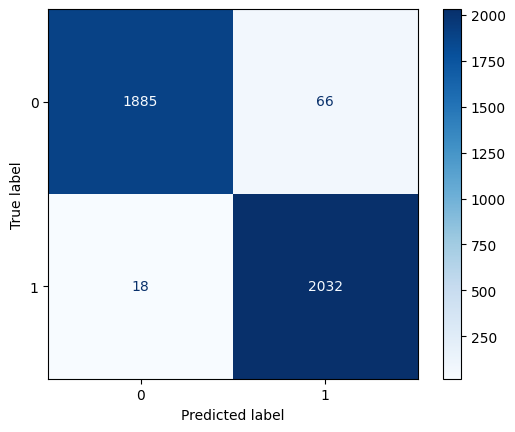

In [53]:
disp=ConfusionMatrixDisplay(confusion_matrix(y_test,predictions))
disp.plot(cmap='Blues')

In [9]:
# Testing the model with custom input
new_email = 'Dear friend, I have a great investment opportunity for you!'
new_email_vectorized = vectorizer.transform([new_email])
prediction = model.predict(new_email_vectorized)
if prediction[0] == 0:
    print('Not Spam')
else:
    print('Spam')

Spam


naive bayes

In [11]:
from sklearn.naive_bayes import MultinomialNB

In [12]:
nb_clf = MultinomialNB()
nb_clf.fit(x_trained_vectorized, y_train)

MultinomialNB()

In [13]:
y_pred_nb = nb_clf.predict(x_test_vectorized )
print(y_pred_nb)

[0 1 0 ... 0 1 1]


In [18]:
print(accuracy_score(y_test,y_pred_nb))
print(f1_score(y_test,y_pred_nb))

0.9725068732816796
0.9728930507639231


In [19]:
print(precision_score(y_test,y_pred_nb))
print(recall_score(y_test,y_pred_nb))
print(confusion_matrix(y_test,y_pred_nb))

0.9830677290836654
0.9629268292682926
[[1917   34]
 [  76 1974]]


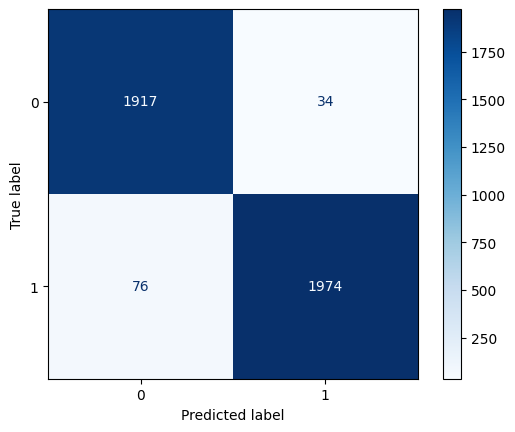

In [23]:
disp=ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred_nb))
disp.plot(cmap='Blues')

In [20]:
# Testing the model with custom input
new_email = 'Dear friend, I have a great investment opportunity for you!'
new_email_vectorized = vectorizer.transform([new_email])
prediction = model.predict(new_email_vectorized)
if prediction[0] == 0:
    print('Not Spam')
else:
    print('Spam')

Spam


xgboost

In [24]:
from xgboost import XGBClassifier

In [25]:
xgb_clf = XGBClassifier(eval_metric='mlogloss')
xgb_clf.fit(x_trained_vectorized, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [29]:
y_pred_xgb = xgb_clf.predict(x_test_vectorized)
print(y_pred_xgb)

[0 1 0 ... 1 1 1]


In [31]:
print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.98      1951
           1       0.96      0.99      0.98      2050

    accuracy                           0.98      4001
   macro avg       0.98      0.98      0.98      4001
weighted avg       0.98      0.98      0.98      4001



In [32]:
print("Accuracy : ", accuracy_score(y_test,y_pred_xgb))
print("F1 score : ", f1_score(y_test,y_pred_xgb))
print("Precision : ", precision_score(y_test,y_pred_xgb))
print("Recall : ", recall_score(y_test,y_pred_xgb))
print("Confusion Matrix : \n", confusion_matrix(y_test,y_pred_xgb))

Accuracy :  0.976005998500375
F1 score :  0.9769230769230769
Precision :  0.9630331753554502
Recall :  0.9912195121951219
Confusion Matrix : 
 [[1873   78]
 [  18 2032]]


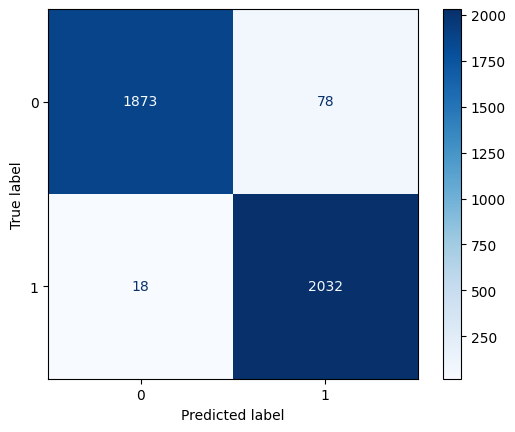

In [37]:
disp=ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred_xgb))
disp.plot(cmap='Blues')

In [52]:
new_email = 'Dear friend, I have a great investment opportunity for you!'
new_email_vectorized = vectorizer.transform([new_email])
prediction = xgb_clf.predict(new_email_vectorized)
if prediction[0] == 0:
    print('Not Spam')
else:
    print('Spam')

Spam


random forest

In [34]:
from sklearn.ensemble import RandomForestClassifier

In [35]:
# Using Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(x_trained_vectorized, y_train)

y_pred_rf = rf_classifier.predict(x_test_vectorized)

In [36]:
accuracy = accuracy_score(y_test, y_pred_rf)
confusion = confusion_matrix(y_test, y_pred_rf)
report = classification_report(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1score= f1_score(y_test, y_pred_rf)

In [38]:
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", confusion)
print("Classification Report:\n", report)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1score)

Accuracy: 0.9740064983754061
Confusion Matrix:
 [[1875   76]
 [  28 2022]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.97      1951
           1       0.96      0.99      0.97      2050

    accuracy                           0.97      4001
   macro avg       0.97      0.97      0.97      4001
weighted avg       0.97      0.97      0.97      4001

Precision: 0.9637750238322211
Recall: 0.9863414634146341
F1 score: 0.9749276759884281


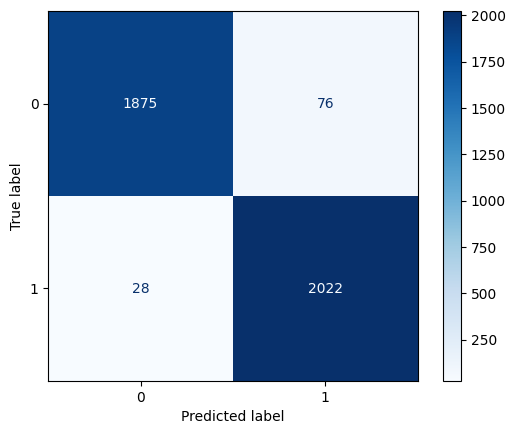

In [39]:
disp=ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred_rf))
disp.plot(cmap='Blues')

In [51]:
new_email = 'Dear friend, I have a great investment opportunity for you!'
new_email_vectorized = vectorizer.transform([new_email])
prediction = rf_classifier.predict(new_email_vectorized)
if prediction[0] == 0:
    print('Not Spam')
else:
    print('Spam')

Spam


boosting

In [40]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

In [46]:
gb_clf = GradientBoostingClassifier()
gb_clf.fit(x_trained_vectorized,y_train)
y_pred_gb = gb_clf.predict(x_test_vectorized)
print("Gradient Boosting Classification Report:\n", classification_report(y_test, y_pred_gb))

Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.90      0.94      1951
           1       0.91      0.99      0.95      2050

    accuracy                           0.95      4001
   macro avg       0.95      0.94      0.95      4001
weighted avg       0.95      0.95      0.95      4001



In [47]:
print("Accuracy : ", accuracy_score(y_test,y_pred_gb))
print("F1 score : ", f1_score(y_test,y_pred_gb))
print("Precision : ", precision_score(y_test,y_pred_gb))
print("Recall : ", recall_score(y_test,y_pred_gb))
print("Confusion Matrix : \n", confusion_matrix(y_test,y_pred_gb))

Accuracy :  0.9460134966258436
F1 score :  0.9494855004677268
Precision :  0.9119496855345912
Recall :  0.9902439024390244
Confusion Matrix : 
 [[1755  196]
 [  20 2030]]


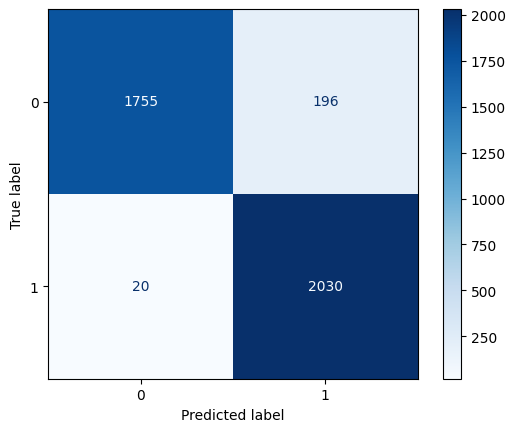

In [49]:
disp=ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred_gb))
disp.plot(cmap='Blues')

In [50]:
new_email = 'Dear friend, I have a great investment opportunity for you!'
new_email_vectorized = vectorizer.transform([new_email])
prediction = gb_clf.predict(new_email_vectorized)
if prediction[0] == 0:
    print('Not Spam')
else:
    print('Spam')

Spam


Model save

In [56]:
from joblib import dump
dump(xgb_clf, 'spam_classifier.joblib')

['spam_classifier.joblib']

In [ ]:
from joblib import load

# Load the saved model from the file
loaded_model = load('spam_classifier.joblib')

In [ ]:
from google.colab import drive
from joblib import dump, load

drive.mount('/content/drive')

# Save the trained model to Google Drive
dump(rf_classifier, 'email_classifier.joblib')

# After saving, you can unmount the drive
drive.flush_and_unmount()

drive.mount('/content/drive')

# Load the saved model from Google Drive
loaded_model = load('email_classifier.joblib')